# Lab 11: Random Walks and a Small GCN

**Purpose:** practice the core graph-learning ideas from the lectures in a compact 50-minute lab.

You will use a synthetic user-subject network with **90 users**. The graph is large enough for a small node-classification experiment, but still simple enough to visualize and debug.


## Big Picture

The lectures move from **random-walk graph embeddings** to **GNN/GCN message passing**.

In this lab:

1. **Random walks** show how graph structure defines neighborhoods.
2. **node2vec** shows how walk behavior can be biased by two parameters, $p$ and $q$.
3. **GCN** replaces walk co-occurrence training with neural propagation over adjacency and node features:

$$
Z^{(l)} = f\left(\hat{A} Z^{(l-1)} W^{(l)}\right).
$$


## Learning Goals

After this lab, students should be able to:

1. represent a graph using an edge list, adjacency matrix, and adjacency list;
2. simulate an unbiased random walk;
3. explain the node2vec parameters $p$ and $q$;
4. build the normalized adjacency matrix $\hat{A}=D^{-1/2}(A+I)D^{-1/2}$;
5. run one GCN layer: propagation $\rightarrow$ linear transformation $\rightarrow$ ReLU;
6. train a small GCN for node classification.


## 0. Setup

Run the next cell first. We use common packages plus PyTorch.


In [5]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

np.set_printoptions(precision=3, suppress=True)
torch.manual_seed(42)
torch.set_num_threads(1)

RANDOM_SEED = 42
rng = random.Random(RANDOM_SEED)
np_rng = np.random.default_rng(RANDOM_SEED)


## 1. Dataset: Synthetic User-Subject Network

Each node is a user. Each user mainly belongs to one subject:

- **AI**
- **Systems**
- **Theory**

Unlike the previous tiny version, this dataset has **30 users per subject**. Edges are denser inside the same subject and sparser across subjects. This creates a homophilous graph: similar nodes are more likely to connect.


In [6]:
subjects = ["AI", "Systems", "Theory"]
users_per_subject = 30
p_in = 0.16
p_out = 0.012

nodes = [f"{subject}_{i:03d}" for subject in subjects for i in range(1, users_per_subject + 1)]
subject_of = {node: node.split("_")[0] for node in nodes}
label_of_subject = {"AI": 0, "Systems": 1, "Theory": 2}
y_np = np.array([label_of_subject[subject_of[node]] for node in nodes], dtype=np.int64)

edges = set()

# Ensure each subject group is connected by a ring.
for subject in subjects:
    group = [f"{subject}_{i:03d}" for i in range(1, users_per_subject + 1)]
    for i in range(users_per_subject):
        edges.add(tuple(sorted((group[i], group[(i + 1) % users_per_subject]))))

# Add random within-subject and cross-subject edges.
for i, u in enumerate(nodes):
    for v in nodes[i + 1:]:
        prob = p_in if subject_of[u] == subject_of[v] else p_out
        if np_rng.random() < prob:
            edges.add((u, v))

# Add a few explicit bridge edges so random walks can move across subjects.
bridge_edges = [
    ("AI_005", "Systems_006"),
    ("AI_014", "Theory_011"),
    ("Systems_020", "Theory_018"),
    ("AI_026", "Systems_025"),
]
for u, v in bridge_edges:
    edges.add(tuple(sorted((u, v))))

edges = sorted(edges)

print("Number of subjects:", len(subjects))
print("Users per subject:", users_per_subject)
print("Number of nodes:", len(nodes))
print("Number of edges:", len(edges))


Number of subjects: 3
Users per subject: 30
Number of nodes: 90
Number of edges: 315


### Visualize the Graph

Colors show the hidden subject. The graph is large enough for training, so node labels are hidden in the plot to keep it readable.


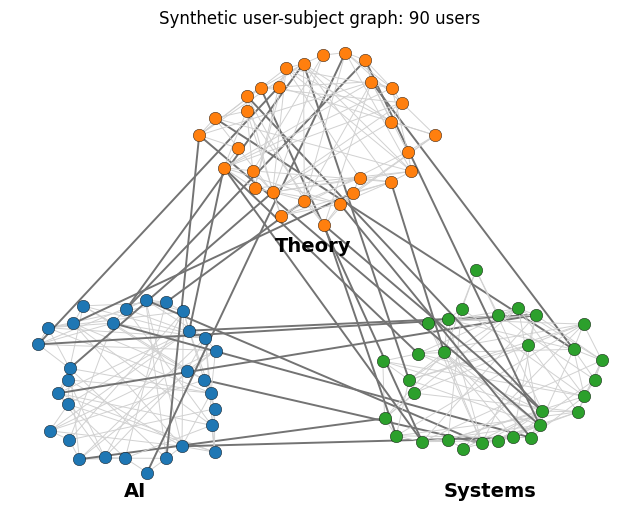

In [7]:
subject_colors = {"AI": "tab:blue", "Systems": "tab:green", "Theory": "tab:orange"}
centers = {"AI": (0.0, 0.0), "Systems": (5.0, 0.0), "Theory": (2.5, 4.2)}

pos = {}
for subject in subjects:
    cx, cy = centers[subject]
    group = [f"{subject}_{i:03d}" for i in range(1, users_per_subject + 1)]
    for k, node in enumerate(group):
        angle = 2 * np.pi * k / users_per_subject
        radius = 1.3 + 0.25 * np_rng.normal()
        pos[node] = (cx + radius * np.cos(angle), cy + radius * np.sin(angle))

plt.figure(figsize=(8, 6))
for u, v in edges:
    x_values = [pos[u][0], pos[v][0]]
    y_values = [pos[u][1], pos[v][1]]
    same_subject = subject_of[u] == subject_of[v]
    plt.plot(x_values, y_values, color="0.82" if same_subject else "0.45", linewidth=0.7 if same_subject else 1.4, zorder=1)

for node in nodes:
    x, y = pos[node]
    plt.scatter(x, y, s=80, color=subject_colors[subject_of[node]], edgecolor="black", linewidth=0.3, zorder=2)

for subject, (cx, cy) in centers.items():
    plt.text(cx, cy - 1.9, subject, ha="center", va="center", fontsize=14, fontweight="bold")

plt.title("Synthetic user-subject graph: 90 users")
plt.axis("off")
plt.show()


## 2. TODO: Build the Adjacency Matrix

The adjacency matrix $A$ stores graph connectivity:

- $A_{ij}=1$ if node $i$ connects to node $j$;
- $A_{ij}=0$ otherwise.

Because this graph is undirected, $A$ should be symmetric.


In [8]:
def build_adjacency_matrix(edge_list, node_order):
    '''Return an adjacency matrix using node_order for rows and columns.'''
    # TODO:
    # 1. Create a dictionary that maps each node name to its row/column index.
    # 2. Create a zero matrix of shape (number_of_nodes, number_of_nodes).
    # 3. For every undirected edge (u, v), set A[u, v] = 1 and A[v, u] = 1.
    node_to_index = {node: index for index, node in enumerate(node_order)}
    adjacency = np.zeros((len(node_order), len(node_order)), dtype=np.float32)
    for u, v in edge_list:
        i = node_to_index[u]
        j = node_to_index[v]
        adjacency[i, j] = 1.0
        adjacency[j, i] = 1.0
    return adjacency


A = build_adjacency_matrix(edges, nodes)
print("Adjacency matrix shape:", A.shape)
pd.DataFrame(A.astype(int), index=nodes, columns=nodes).iloc[:10, :10]


Adjacency matrix shape: (90, 90)


,AI_001,AI_002,AI_003,AI_004,AI_005,AI_006,AI_007,AI_008,AI_009,AI_010
AI_001,0,1,0,0,0,1,0,0,0,1
AI_002,1,0,1,1,0,0,0,0,0,0
AI_003,0,1,0,1,0,0,0,0,0,0
AI_004,0,1,1,0,1,0,0,1,1,1
AI_005,0,0,0,1,0,1,0,0,0,0
AI_006,1,0,0,0,1,0,1,1,0,0
AI_007,0,0,0,0,0,1,0,1,0,0
AI_008,0,0,0,1,0,1,1,0,1,0
AI_009,0,0,0,1,0,0,0,1,0,1
AI_010,1,0,0,1,0,0,0,0,1,0


In [9]:
assert isinstance(A, np.ndarray)
assert A.shape == (len(nodes), len(nodes))
assert np.allclose(A, A.T), "Undirected graph adjacency matrix should be symmetric."
assert np.all(np.diag(A) == 0), "This graph should not contain self-loops yet."
assert int(A.sum() / 2) == len(edges), "Each undirected edge should appear twice in A."

print("Adjacency matrix checks passed.")


Adjacency matrix checks passed.


### Adjacency List

A random walk is easier to simulate from an adjacency list: `node -> list of neighbors`.


In [10]:
def build_adjacency_list(edge_list, node_order):
    adjacency_list = {node: [] for node in node_order}
    for u, v in edge_list:
        adjacency_list[u].append(v)
        adjacency_list[v].append(u)
    return {node: sorted(neighbors) for node, neighbors in adjacency_list.items()}


adjacency_list = build_adjacency_list(edges, nodes)
degrees = A.sum(axis=1).astype(int)

pd.DataFrame({
    "node": nodes,
    "subject": [subject_of[n] for n in nodes],
    "degree": degrees,
}).sort_values("degree", ascending=False).head(10)


,node,subject,degree
80,Theory_021,Theory,13
57,Systems_028,Systems,12
42,Systems_013,Systems,12
56,Systems_027,Systems,11
52,Systems_023,Systems,11
77,Theory_018,Theory,11
3,AI_004,AI,11
64,Theory_005,Theory,10
59,Systems_030,Systems,10
14,AI_015,AI,10


## 3. TODO: Simulate an Unbiased Random Walk

A simple random walk starts at one node. At each step, it randomly moves to one of the current node's neighbors.

This is the basic walk idea behind DeepWalk-style graph representation learning.


In [11]:
def random_walk(start_node, steps, adjacency_list, rng):
    '''Return a list of visited nodes from a simple random walk.'''
    # TODO:
    # 1. Start the path with start_node.
    # 2. Repeat `steps` times:
    #    - get the current node's neighbors;
    #    - randomly choose one neighbor;
    #    - append it to the path.
    path = [start_node]
    for _ in range(steps):
        current_node = path[-1]
        neighbors = adjacency_list[current_node]
        if not neighbors:
            break
        path.append(rng.choice(neighbors))
    return path


example_path = random_walk("AI_001", steps=12, adjacency_list=adjacency_list, rng=random.Random(7))
print(" -> ".join(example_path))


AI_001 -> AI_010 -> AI_009 -> AI_028 -> AI_029 -> AI_001 -> AI_002 -> AI_012 -> AI_002 -> AI_004 -> AI_027 -> AI_004 -> AI_021


In [12]:
test_path = random_walk("AI_001", steps=8, adjacency_list=adjacency_list, rng=random.Random(1))
assert len(test_path) == 9
assert test_path[0] == "AI_001"
for current_node, next_node in zip(test_path, test_path[1:]):
    assert next_node in adjacency_list[current_node] or current_node == next_node
print("Random walk checks passed.")


Random walk checks passed.


### Visit Scores From Repeated Walks

One walk is noisy. Repeated walks give a probability-like score: nodes visited more often receive larger values.

This is an intuitive version of a random-walk neighborhood $N_R(u)$.


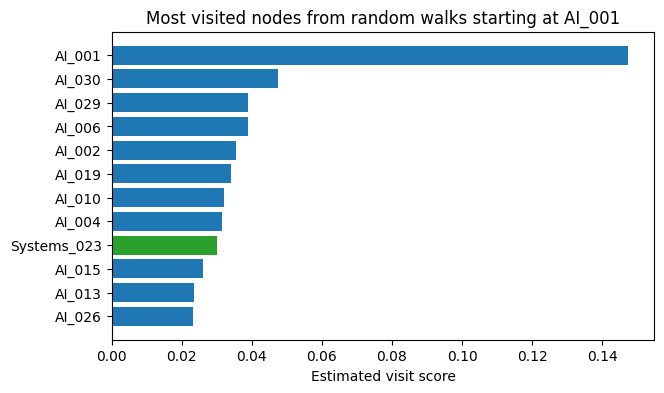

In [13]:
def estimate_visit_scores(start_node, num_walks, steps, adjacency_list, rng):
    counts = Counter()
    for _ in range(num_walks):
        path = random_walk(start_node, steps, adjacency_list, rng)
        counts.update(path)
    total = sum(counts.values())
    return {node: counts[node] / total for node in adjacency_list}


visit_scores = estimate_visit_scores(
    start_node="AI_001",
    num_walks=400,
    steps=8,
    adjacency_list=adjacency_list,
    rng=random.Random(10),
)

visit_series = pd.Series(visit_scores).sort_values(ascending=False).head(12).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(visit_series.index, visit_series.values, color=[subject_colors[subject_of[n]] for n in visit_series.index])
plt.xlabel("Estimated visit score")
plt.title("Most visited nodes from random walks starting at AI_001")
plt.show()


## 4. node2vec in One Cell: Bias the Walk

DeepWalk chooses uniformly among neighbors.

node2vec changes the next-step weights using two parameters:

- $p$: return parameter. Low $p$ makes going back to the previous node more likely.
- $q$: in-out parameter. Low $q$ encourages outward movement; high $q$ keeps the walk more local.

We only inspect transition weights, because the main GCN part comes next.


In [14]:
def node2vec_transition_weights(previous_node, current_node, adjacency_list, p, q):
    candidates = adjacency_list[current_node]
    previous_neighbors = set(adjacency_list[previous_node])
    rows = []

    for x in candidates:
        if x == previous_node:
            weight = 1 / p
            relation = "return"
        elif x in previous_neighbors:
            weight = 1.0
            relation = "near previous node"
        else:
            weight = 1 / q
            relation = "outward"
        rows.append((x, relation, weight))

    return pd.DataFrame(rows, columns=["candidate", "relation", "unnormalized_weight"])


for q in [0.5, 1.0, 4.0]:
    print(f"q = {q}")
    display(node2vec_transition_weights("AI_001", "AI_002", adjacency_list, p=1.0, q=q).head(12))


q = 0.5


,candidate,relation,unnormalized_weight
0,AI_001,return,1.0
1,AI_003,outward,2.0
2,AI_004,outward,2.0
3,AI_011,outward,2.0
4,AI_012,outward,2.0
5,AI_022,outward,2.0


q = 1.0


,candidate,relation,unnormalized_weight
0,AI_001,return,1.0
1,AI_003,outward,1.0
2,AI_004,outward,1.0
3,AI_011,outward,1.0
4,AI_012,outward,1.0
5,AI_022,outward,1.0


q = 4.0


,candidate,relation,unnormalized_weight
0,AI_001,return,1.00
1,AI_003,outward,0.25
2,AI_004,outward,0.25
3,AI_011,outward,0.25
4,AI_012,outward,0.25
5,AI_022,outward,0.25


## 5. From Random Walks to GCN

Random walks define neighborhoods by sampled paths.

GCN uses a different idea: every layer aggregates from immediate neighbors using the normalized adjacency matrix:

$$
\hat{A} = D^{-1/2}(A+I)D^{-1/2}.
$$

The $+I$ adds self-loops, so each node keeps its own information while receiving neighbor information.


### Node Feature Matrix $X$

Each row is a user. Each column is a simple numeric attribute.

The features are noisy but correlated with the hidden subject. This makes the task realistic enough for training while keeping the lab simple.


In [15]:
# Six simple features:
# - 3 subject activity features
# - normalized degree
# - 2 small noise features
X_np = np.zeros((len(nodes), 6), dtype=np.float32)
feature_rng = np.random.default_rng(123)

for i, node in enumerate(nodes):
    subject = subject_of[node]
    X_np[i, :3] = 0.25 + 0.18 * feature_rng.normal(size=3)
    X_np[i, label_of_subject[subject]] += 0.70

X_np[:, 3] = degrees / degrees.max()
X_np[:, 4:] = 0.20 * feature_rng.normal(size=(len(nodes), 2))
X_np = np.clip(X_np, -1.0, None)

feature_names = ["AI_activity", "Systems_activity", "Theory_activity", "degree", "noise_1", "noise_2"]
pd.DataFrame(X_np, index=nodes, columns=feature_names).head(10)


,AI_activity,Systems_activity,Theory_activity,degree,noise_1,noise_2
AI_001,0.771958,0.183798,0.481827,0.538462,0.195195,0.066956
AI_002,0.984915,0.415642,0.353879,0.461538,0.023284,0.013690
AI_003,0.835437,0.347551,0.193013,0.461538,-0.017262,0.081506
AI_004,0.891970,0.267490,-0.024667,0.846154,-0.079445,-0.391541
AI_005,1.164590,0.129204,0.430048,0.615385,0.015560,-0.092119
AI_006,0.974538,0.525766,0.131205,0.615385,-0.275384,0.156137
AI_007,0.893877,0.310798,-0.147345,0.461538,-0.076049,-0.349047
AI_008,1.099026,0.527493,0.452825,0.615385,-0.014953,-0.134953
AI_009,1.085859,0.223724,0.480742,0.461538,-0.340309,0.062437
AI_010,1.143326,0.320672,0.250921,0.615385,-0.210112,0.143674


## 6. TODO: Build Normalized Adjacency $\hat{A}$

Complete the function below.

Steps:

1. Add self-loops: $\tilde{A}=A+I$.
2. Compute the degree vector of $\tilde{A}$.
3. Build $D^{-1/2}$.
4. Return $D^{-1/2}\tilde{A}D^{-1/2}$.


In [16]:
def normalize_adjacency(A):
    '''Return D^{-1/2} (A + I) D^{-1/2}.'''
    # TODO:
    # 1. Add self-loops to A.
    # 2. Compute the degree vector.
    # 3. Build a diagonal matrix with entries 1 / sqrt(degree).
    # 4. Return D_inv_sqrt @ A_tilde @ D_inv_sqrt.
    A_tilde = A + np.eye(A.shape[0], dtype=A.dtype)
    degree = A_tilde.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree))
    return D_inv_sqrt @ A_tilde @ D_inv_sqrt


A_hat_np = normalize_adjacency(A)
print("A_hat shape:", A_hat_np.shape)
pd.DataFrame(A_hat_np, index=nodes, columns=nodes).iloc[:10, :10]


A_hat shape: (90, 90)


,AI_001,AI_002,AI_003,AI_004,AI_005,AI_006,AI_007,AI_008,AI_009,AI_010
AI_001,0.125000,0.133631,0.000000,0.000000,0.000000,0.117851,0.000000,0.000000,0.000000,0.117851
AI_002,0.133631,0.142857,0.142857,0.109109,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AI_003,0.000000,0.142857,0.142857,0.109109,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AI_004,0.000000,0.109109,0.109109,0.083333,0.096225,0.000000,0.000000,0.096225,0.109109,0.096225
AI_005,0.000000,0.000000,0.000000,0.096225,0.111111,0.111111,0.000000,0.000000,0.000000,0.000000
AI_006,0.117851,0.000000,0.000000,0.000000,0.111111,0.111111,0.125988,0.111111,0.000000,0.000000
AI_007,0.000000,0.000000,0.000000,0.000000,0.000000,0.125988,0.142857,0.125988,0.000000,0.000000
AI_008,0.000000,0.000000,0.000000,0.096225,0.000000,0.111111,0.125988,0.111111,0.125988,0.000000
AI_009,0.000000,0.000000,0.000000,0.109109,0.000000,0.000000,0.000000,0.125988,0.142857,0.125988
AI_010,0.117851,0.000000,0.000000,0.096225,0.000000,0.000000,0.000000,0.000000,0.125988,0.111111


In [17]:
assert isinstance(A_hat_np, np.ndarray)
assert A_hat_np.shape == A.shape
assert np.allclose(A_hat_np, A_hat_np.T), "Normalized adjacency should be symmetric."
assert np.all(np.diag(A_hat_np) > 0), "Self-loops should make diagonal entries positive."
print("Normalized adjacency checks passed.")


Normalized adjacency checks passed.


## 7. TODO: One GCN Layer

A GCN layer has three lecture components:

1. **Propagation:** $\hat{A}Z$
2. **Linear transformation:** $(\hat{A}Z)W$
3. **Activation:** ReLU

Complete the NumPy version below:

$$
H = \mathrm{ReLU}(\hat{A}ZW).
$$


In [18]:
def relu(x):
    return np.maximum(x, 0)


def gcn_layer(Z, A_hat, W):
    '''One GCN layer: ReLU(A_hat @ Z @ W).'''
    # TODO: implement propagation, linear transformation, and ReLU.
    propagated = A_hat @ Z
    transformed = propagated @ W
    return relu(transformed)


W_demo = np.random.default_rng(0).normal(0, 0.5, size=(X_np.shape[1], 2)).astype(np.float32)
H_demo = gcn_layer(X_np, A_hat_np, W_demo)
print("Hidden representation shape:", H_demo.shape)
pd.DataFrame(H_demo, index=nodes, columns=["hidden_1", "hidden_2"]).head(10)


Hidden representation shape: (90, 2)


,hidden_1,hidden_2
AI_001,0.458874,0.308585
AI_002,0.318200,0.215027
AI_003,0.434320,0.242842
AI_004,0.539029,0.382250
AI_005,0.459659,0.331177
AI_006,0.441820,0.302031
AI_007,0.434901,0.338415
AI_008,0.613069,0.401629
AI_009,0.462154,0.338922
AI_010,0.452961,0.331309


In [19]:
assert H_demo.shape == (len(nodes), 2)
assert np.all(H_demo >= 0), "ReLU output should be non-negative."
print("GCN layer checks passed.")


GCN layer checks passed.


## 8. Train a Small 2-Layer GCN for Node Classification

Now we train a small GCN to predict each user's subject.

We label only **8 users per subject** and ask the model to classify the remaining nodes.

The training code is provided so the lab stays short.


In [20]:
X = torch.tensor(X_np, dtype=torch.float32)
A_hat = torch.tensor(A_hat_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

train_idx = []
for subject in subjects:
    group = [i for i, node in enumerate(nodes) if subject_of[node] == subject]
    train_idx.extend(group[:8])

train_idx = torch.tensor(train_idx, dtype=torch.long)
test_idx = torch.tensor([i for i in range(len(nodes)) if i not in set(train_idx.tolist())], dtype=torch.long)

print("Number of train nodes:", len(train_idx))
print("Number of test nodes:", len(test_idx))


Number of train nodes: 24
Number of test nodes: 66


In [21]:
class TinyGCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.W1 = torch.nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.2)
        self.W2 = torch.nn.Parameter(torch.randn(hidden_dim, output_dim) * 0.2)

    def forward(self, X, A_hat):
        H = torch.relu(A_hat @ X @ self.W1)
        logits = A_hat @ H @ self.W2
        return logits


model = TinyGCN(input_dim=X.shape[1], hidden_dim=12, output_dim=len(subjects))
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

loss_history = []
for epoch in range(121):
    model.train()
    logits = model(X, A_hat)
    loss = F.cross_entropy(logits[train_idx], y[train_idx])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.item()))

    if epoch % 30 == 0:
        pred = logits.argmax(dim=1)
        train_acc = (pred[train_idx] == y[train_idx]).float().mean().item()
        test_acc = (pred[test_idx] == y[test_idx]).float().mean().item()
        print(f"epoch={epoch:03d} | loss={loss.item():.4f} | train_acc={train_acc:.2f} | test_acc={test_acc:.2f}")


epoch=000 | loss=1.1181 | train_acc=0.12 | test_acc=0.14
epoch=030 | loss=0.0061 | train_acc=1.00 | test_acc=1.00
epoch=060 | loss=0.0010 | train_acc=1.00 | test_acc=1.00
epoch=090 | loss=0.0008 | train_acc=1.00 | test_acc=1.00
epoch=120 | loss=0.0006 | train_acc=1.00 | test_acc=1.00


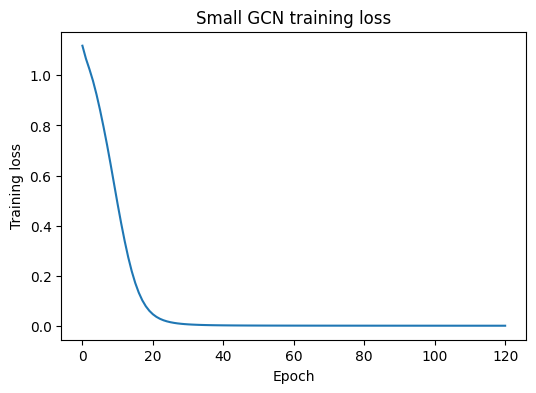

In [22]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Small GCN training loss")
plt.show()

## 9. Evaluate on the Test Set

The model was trained only on the labeled training nodes. Now we evaluate it on the unseen test nodes.

In this lab, **test accuracy** means:

$$
\text{Test Accuracy} = \frac{\text{number of correctly predicted test nodes}}{\text{number of test nodes}}
$$

In [23]:
model.eval()
with torch.no_grad():
    logits = model(X, A_hat)
    pred = logits.argmax(dim=1)

train_acc = (pred[train_idx] == y[train_idx]).float().mean().item()
test_acc = (pred[test_idx] == y[test_idx]).float().mean().item()
overall_acc = (pred == y).float().mean().item()

print(f"Train accuracy:   {train_acc:.3f}")
print(f"Test accuracy:    {test_acc:.3f}")
print(f"Overall accuracy: {overall_acc:.3f}")

id_to_subject = {v: k for k, v in label_of_subject.items()}
result_table = pd.DataFrame({
    "node": nodes,
    "true_subject": [subject_of[n] for n in nodes],
    "predicted_subject": [id_to_subject[int(p)] for p in pred.numpy()],
    "split": ["train" if i in set(train_idx.tolist()) else "test" for i in range(len(nodes))],
})

# Display a few test nodes so we can inspect mistakes.
result_table[result_table["split"] == "test"].head(15)

Train accuracy:   1.000
Test accuracy:    1.000
Overall accuracy: 1.000


,node,true_subject,predicted_subject,split
8,AI_009,AI,AI,test
9,AI_010,AI,AI,test
10,AI_011,AI,AI,test
11,AI_012,AI,AI,test
12,AI_013,AI,AI,test
13,AI_014,AI,AI,test
14,AI_015,AI,AI,test
15,AI_016,AI,AI,test
16,AI_017,AI,AI,test
17,AI_018,AI,AI,test


## 10. Reflection Questions

1. Why is the adjacency matrix symmetric in this dataset?
2. Why can two random walks from the same starting node produce different paths?
3. In node2vec, what is the role of $q$?
4. Why does GCN add self-loops before normalization?
5. In the GCN layer, which part performs neighborhood propagation?
6. What is the difference between random-walk neighborhoods and GCN message passing?
7. Why can the GCN predict labels for nodes that were not used for training?


1. The adjacency matrix is symmetric because the graph is undirected. If `u` connects to `v`, then `v` also connects to `u`, so both `A[i, j]` and `A[j, i]` are `1`.

2. Two random walks from the same starting node can produce different paths because each step randomly chooses among the current node's neighbors. Different random choices produce different sequences.

3. In node2vec, `q` is the in-out parameter. It controls whether the walk stays local or moves outward: low `q` favors exploration, while high `q` favors remaining near the previous node.

4. GCN adds self-loops so each node keeps its own feature information during aggregation. Without self-loops, a node update would depend only on neighbors and not on itself.

5. Neighborhood propagation is performed by multiplying with `A_hat`, i.e. `A_hat @ Z`. This is the step that aggregates information from adjacent nodes.

6. Random-walk neighborhoods are stochastic, path-based neighborhoods collected by sampling over multiple steps. GCN message passing is deterministic local aggregation from immediate neighbors at each layer using the normalized adjacency matrix.

7. The GCN can predict labels for unlabeled nodes because it learns shared weights from the labeled nodes and uses graph structure plus node features to compute representations for every node, not just the training nodes.
